Copyright and License
© 2026, Jaime Rodríguez Membrive

This Jupyter Notebook is licensed under the MIT License.

Disclaimer:

- This notebook is provided “as is”, without warranty of any kind, express or implied.
- The author assumes no responsibility or liability for any errors, omissions, or outcomes resulting from the use of this notebook or its contents.
- All analyses and interpretations are for educational and research purposes only and do not constitute medical or clinical advice.

Dataset Note:

This project is built upon a high-fidelity synthetic dataset, meticulously engineered to mirror the deterministic physical relationships and stochastic behaviors inherent in real-world mobile networks

---

# 0. Abstract: Machine Learning-Based KPI Trend Prediction

The primary objective of developing a Time-Series KPI Trend Predictor is to move from reactive network troubleshooting to proactive resource planning. By analyzing historical trends of Key Performance Indicators (KPIs) such as user traffic counts and Throughput (THP), this notebook implements advanced deep learning architectures (Seq2Seq with LSTM) to forecast future network states. 

Effective trend prediction allows operators to anticipate congestion, optimize energy consumption, and ensure high Quality of Service (QoS) during peak hours. This activity models the temporal dependencies within network traffic to provide a multi-day look-ahead horizon.

**Learning Objectives:**
By completing this notebook, students will be able to:
1. Understand the fundamentals of time-series forecasting for network KPIs
2. Implement and compare multiple deep learning architectures
3. Evaluate model performance using industry-standard metrics
4. Recognize the "Horizon Challenge" in long-term forecasting
5. Apply best practices for model deployment in production environments

**Real-World Context:**
Network operators face daily challenges:
- Capacity planning requires accurate traffic forecasts
- Proactive maintenance depends on anomaly prediction
- Resource optimization needs trend analysis
- SLA compliance requires performance monitoring

# 1. Executive Summary

This notebook demonstrates a complete end-to-end pipeline for Multivariate Time-Series Forecasting. 

- **Data Processing**: We ingest historical network KPIs, applying windowing techniques to create sequences suitable for Recurrent Neural Networks (RNNs).
- **Architecture**: The core model is a Sequence-to-Sequence (Seq2Seq) Encoder-Decoder architecture, designed to capture long-term temporal patterns better than standard regression models.
- **Benchmark**: We compare the deep learning results against a 'Persistence' baseline to validate the actual value added by the model.
- **Key Findings**: The analysis highlights the "Horizon Challenge," where predictive power naturally decays as the forecast window extends, emphasizing the need for robust feature engineering and periodic model retraining.

# 2. Analytical Framework Design

The forecasting system is built using a Sequence-to-Sequence (Seq2Seq) architecture. The model is designed to map an input sequence of historical KPI data to a future sequence of predicted values.

- Input Window: 30 days of historical observations.
- Forecast Horizon: 30 days of predicted future values
- Evaluation Metric: The primary metric for assessing prediction error is Mean Absolute Percentage Error (MAPE), which provides a relative measure of accuracy across different KPI scales.

# 3. Data Source & Ethical Considerations

The data utilized is a synthetic generation of 5G/LTE Performance Management (PM) counters. 
- **Privacy**: No User-Plan (UP) data or PII (Personally Identifiable Information) is included.
- **Ethics**: This tool is intended for network optimization and should be used in compliance with local telecommunications regulations regarding data retention.

# 4. Setup & Library Imports

The environment is configured with standard deep learning and time-series libraries. Note that while MSE is a standard loss function, we specifically import mean_absolute_percentage_error from sklearn.metrics to quantify the relative performance of our trend predictions.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Dropout, Input, GRU, Attention, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import ipywidgets as widgets
from IPython.display import display

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)

# 5. Data Ingestion

We load the `network_kpis_2_years.parquet` dataset. The dataset contains multi-year network statistics grouped by day, including:
- **Connected_UEs**: Number of connected user equipment
- **PRB_Util**: Physical Resource Block utilization
- **DL_Throughput**: Downlink throughput
- **Drop_Rate**: Connection drop rate

In [2]:
df = pd.read_parquet('../dataset/network_kpis_2_years.parquet')

df.reset_index(inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.head()

,Connected_UEs,PRB_Util,DL_Throughput,Drop_Rate
Date,,,,
2024-01-01,99.782002,36.617302,53.531394,0.018731
2024-01-02,105.934654,40.052038,48.582816,0.001905
2024-01-03,114.053453,45.315421,48.193744,0.022739
2024-01-04,106.149934,40.117517,53.130477,0.013974
2024-01-05,95.784332,35.056594,56.973803,0.009478


In [3]:
# Interactive data explorer
def explore_kpi(kpi_name, window_size=30):
    """Interactive KPI visualization"""
    plt.figure(figsize=(15, 5))
    
    # Plot full series
    plt.subplot(1, 2, 1)
    plt.plot(df.index, df[kpi_name])
    plt.title(f'{kpi_name} - Full Time Series')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.grid(True, alpha=0.3)
    
    # Plot rolling statistics
    plt.subplot(1, 2, 2)
    rolling_mean = df[kpi_name].rolling(window=window_size).mean()
    rolling_std = df[kpi_name].rolling(window=window_size).std()
    
    plt.plot(df.index, df[kpi_name], label='Original', alpha=0.5)
    plt.plot(df.index, rolling_mean, label=f'{window_size}-day MA', linewidth=2)
    plt.fill_between(df.index, 
                     rolling_mean - rolling_std, 
                     rolling_mean + rolling_std, 
                     alpha=0.2, label='±1 Std Dev')
    plt.title(f'{kpi_name} - Rolling Statistics')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Display statistics
    print(f"\n{kpi_name} Statistics:")
    print(f"Mean: {df[kpi_name].mean():.2f}")
    print(f"Std Dev: {df[kpi_name].std():.2f}")
    print(f"Min: {df[kpi_name].min():.2f}")
    print(f"Max: {df[kpi_name].max():.2f}")
    print(f"Missing Values: {df[kpi_name].isna().sum()}")

if False:
    # Create interactive widget
    kpi_selector = widgets.Dropdown(
        options=df.columns.tolist(),
        value=df.columns[0],
        description='KPI:',
    )

    window_slider = widgets.IntSlider(
        value=30,
        min=7,
        max=90,
        step=7,
        description='Window:',
    )

    widgets.interact(explore_kpi, kpi_name=kpi_selector, window_size=window_slider)

# 5.1. Enhanced Data Validation

Performing comprehensive data quality checks before proceeding with model training.

In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Data range validation
print("\nData Range Validation:")
for col in ['Connected_UEs', 'PRB_Util', 'DL_Throughput', 'Drop_Rate']:
    if col in df.columns:
        print(f"{col}: min={df[col].min():.2f}, max={df[col].max():.2f}")
        if df[col].min() < 0:
            print(f"  WARNING: Negative values found in {col}")

# Check data quality
print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total days: {len(df)}")

Missing values per column:
Connected_UEs    0
PRB_Util         0
DL_Throughput    0
Drop_Rate        0
dtype: int64

Total missing values: 0

Statistical Summary:
       Connected_UEs    PRB_Util  DL_Throughput   Drop_Rate
count     730.000000  730.000000     730.000000  730.000000
mean      149.260372   56.747134      38.136362    0.023921
std        30.087396   11.477342       8.550625    0.018984
min        87.594252   31.471628      24.233465    0.000023
25%       122.564206   46.202207      30.986953    0.008269
50%       153.717534   58.144393      36.146791    0.019580
75%       172.634311   66.088307      44.919537    0.035709
max       213.284526   81.838459      61.728797    0.095624

Data Range Validation:
Connected_UEs: min=87.59, max=213.28
PRB_Util: min=31.47, max=81.84
DL_Throughput: min=24.23, max=61.73
Drop_Rate: min=0.00, max=0.10

Dataset shape: (730, 4)
Date range: 2024-01-01 00:00:00 to 2025-12-30 00:00:00
Total days: 730


# 6. Data Cleaning & Feature Engineering

In this stage, we prepare the multivariate time series for the LSTM model.

- **Cyclical Feature Encoding**:  It is used to transform periodic temporal data (like days of the week, months, or hours) into a format that a machine learning model, such as an LSTM, can mathematically interpret as a continuous cycle. If we represent the days of the week as integers ($0$ for Monday, $6$ for Sunday), the model perceives a large numerical distance between Sunday ($6$) and Monday ($0$). Mathematically, $6$ is far from $0$.
However, in reality, Monday follows Sunday immediately. By mapping these values onto a circle using Sine and Cosine, the "end" of the cycle (Sunday) is geometrically placed right next to the "start" of the cycle (Monday).This creates day_sin & day_cos features

- **Feature Set**: To maintain maximum information density, the model utilizes the full feature set including the engineered cyclical features (6 features total: 4 original + 2 cyclical), including Drop_Rate and the cyclical temporal features (day_sin, day_cos).

- **Scaling**: All features are transformed using MinMaxScaler to a range of $[0, 1]$. This includes the cyclical features, ensuring that all inputs to the LSTM layers are on a unified scale to prevent gradient instability.

- **Data Splitting**: The dataset is partitioned chronologically into a Training Set (85%) and a Testing Set (15%). This split ensures the model is validated on the most recent data segment to test its generalization on future trends.

- **Sequence Generation**: We implement a sliding window approach where each sample $X$ is a tensor of shape $(30, 6)$, and the corresponding target $y$ is a vector/tensor representing the subsequent 30-day horizon.

In [5]:
# Feature Engineering: Cyclic Time Encoding
df['day_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['day_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)

In [6]:
def create_windows(data, n_in, n_out):
    """Creates sliding window samples for training."""
    X, y = [], []
    for i in range(len(data) - n_in - n_out + 1):
        X.append(data[i:(i + n_in), :])
        y.append(data[(i + n_in):(i + n_in + n_out), :])
    return np.array(X), np.array(y)

scaler = MinMaxScaler()
n_in, n_out = 30, 30 # Increased lookback to 30 days to match the forecast horizon
n_features = df.shape[1]

scaled_data = scaler.fit_transform(df)
X, y = create_windows(scaled_data, n_in, n_out)

# We take the last window for the true final comparison
train_split = int(len(X) * 0.85)
X_train, X_test = X[:train_split], X[train_split:]
y_train, y_test = y[:train_split], y[train_split:]

# 7. Exploratory Data Analysis (EDA)

Visualizing the raw KPI trends to understand seasonality and potential anomalies before modeling.

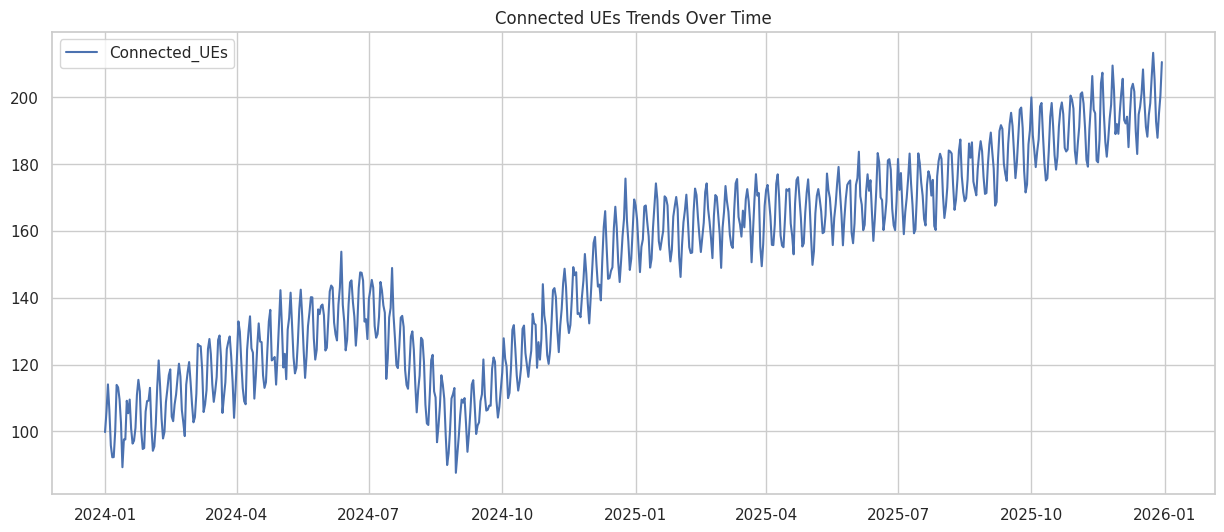

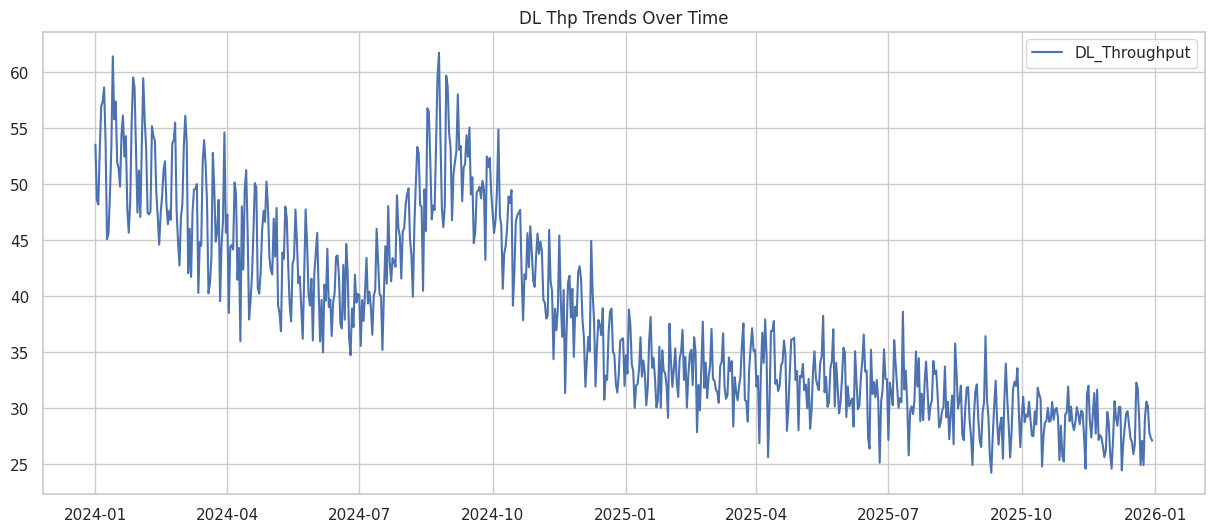

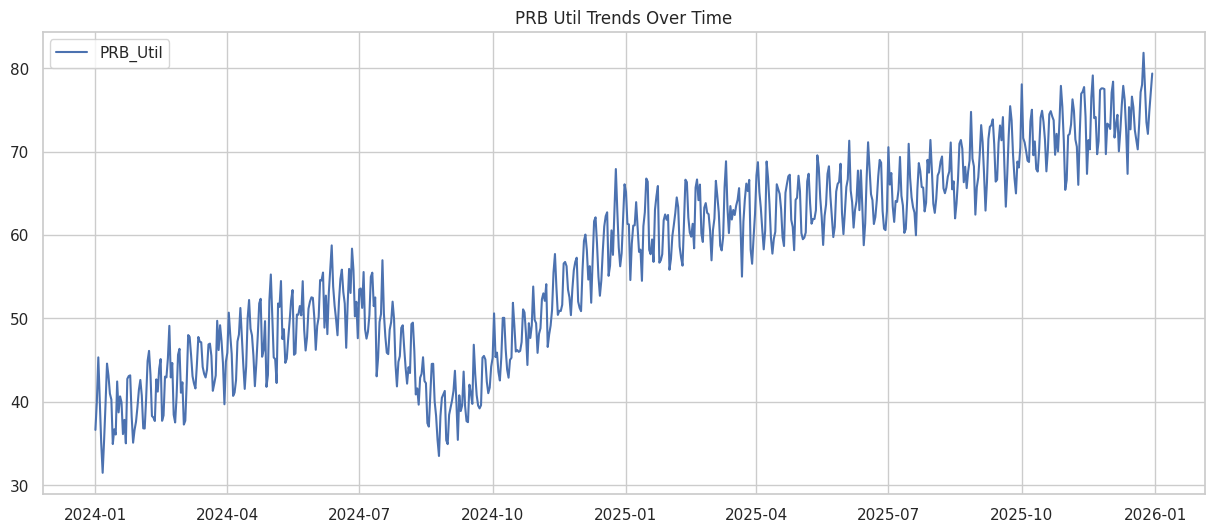

In [7]:
plt.figure(figsize=(15, 6))
plt.plot(df['Connected_UEs'], label='Connected_UEs')
plt.title('Connected UEs Trends Over Time')
plt.legend()
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(df['DL_Throughput'], label='DL_Throughput')
plt.title('DL Thp Trends Over Time')
plt.legend()
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(df['PRB_Util'], label='PRB_Util')
plt.title('PRB Util Trends Over Time')
plt.legend()
plt.show()

# 8. Model Development:

To determine the best approach for KPI forecasting, we implement and compare two distinct deep learning architectures. Both models utilize a 30-day input sequence to predict a 30-day future horizon.

## Simple LSTM (simple Architecture)
The Simple LSTM acts as our primary deep learning baseline. It consists of a single LSTM layer followed by a fully connected output layer.

- Mechanism: The LSTM processes the input sequence and the final hidden state is passed to a Dense layer.

- Limitation: This model treats the 30-day forecast as a single "vector" output. It lacks a specific temporal structure for the output sequence, often leading to less precision as the forecast horizon increases.

##  Seq2Seq LSTM (Encoder-Decoder Architecture)
The Seq2Seq model is a more sophisticated approach designed specifically for mapping variable-length input sequences to variable-length output sequences.

- Encoder: An LSTM layer that reads the input sequence and compresses the "context" into a fixed-length internal representation (the context vector).

- Bridge: A RepeatVector layer that feeds this context vector into the decoder for every time step of the predicted horizon.

- Decoder: An LSTM layer that "unfolds" the context vector back into a time series.

- Output: A TimeDistributed(Dense) layer that ensures the same weight matrix is applied to every time step of the generated forecast, maintaining temporal consistency.

## GRU-based Seq2Seq model
    
Advantages over LSTM:
- Fewer parameters
- Faster training
- Often comparable performance
- Better for smaller datasets

## Seq2Seq with Attention

Advantages:
- Decoder can "attend" to different parts of input sequence
- Helps with long-term dependencies
- More interpretable (attention weights show what model focuses on)

In [29]:
def build_gru_seq2seq(n_in, n_out, n_features, units=64):

    # Encoder
    encoder_inputs = Input(shape=(n_in, n_features))
    encoder = GRU(units, return_state=True)
    encoder_outputs, state_h = encoder(encoder_inputs)
    
    # Decoder
    decoder_inputs = RepeatVector(n_out)(state_h)
    decoder_gru = GRU(units, return_sequences=True)
    decoder_outputs = decoder_gru(decoder_inputs)
    
    # Output layer
    outputs = TimeDistributed(Dense(n_features))(decoder_outputs)
    
    model = Model(encoder_inputs, outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    return model

def build_simple_lstm(n_in, n_features, n_out):
    """Standard LSTM with a single Dense output layer (Many-to-Many)."""
    model = Sequential([
        LSTM(128, activation='tanh', input_shape=(n_in, n_features)),
        Dropout(0.2),
        Dense(n_out * n_features),
        tf.keras.layers.Reshape((n_out, n_features))
    ])
    model.compile(optimizer='adam', loss='huber')
    return model

def build_seq2seq_model(n_in, n_features, n_out):
    """
    Advanced Encoder-Decoder architecture with increased capacity 
    to prevent over-smoothing.
    """
    model = Sequential([
        # Encoder
        LSTM(150, activation='tanh', input_shape=(n_in, n_features), return_sequences=False),
        RepeatVector(n_out),
        # Decoder
        LSTM(150, activation='tanh', return_sequences=True),
        TimeDistributed(Dense(100, activation='relu')),
        Dropout(0.1),
        TimeDistributed(Dense(n_features))
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='huber')
    return model

def build_attention_seq2seq(n_in, n_out, n_features, units=64):
    """
    
    """
    # Encoder
    encoder_inputs = Input(shape=(n_in, n_features))
    encoder = LSTM(units, return_sequences=True, return_state=True)
    encoder_outputs, state_h, state_c = encoder(encoder_inputs)
    
    # Decoder with attention
    decoder_inputs = RepeatVector(n_out)(state_h)
    decoder_lstm = LSTM(units, return_sequences=True)
    decoder_outputs = decoder_lstm(decoder_inputs, initial_state=[state_h, state_c])
    
    # Attention mechanism
    attention = Attention()
    context_vector = attention([decoder_outputs, encoder_outputs])
    
    # Combine context with decoder output
    decoder_combined = Concatenate()([decoder_outputs, context_vector])
    
    # Output layer
    outputs = TimeDistributed(Dense(n_features))(decoder_combined)
    
    model = Model(encoder_inputs, outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    return model

In [22]:
models = {
    "Attention LSTM": build_attention_seq2seq(n_in, n_out, n_features),
    "Simple LSTM": build_simple_lstm(n_in, n_features, n_out),
    "Seq2Seq LSTM": build_seq2seq_model(n_in, n_features, n_out),
    "GRU Seq2Seq" : build_gru_seq2seq(n_in, n_out, n_features),
}

results = {}
# Increased patience and added LR reduction to help Seq2Seq converge
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
]

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train, 
                epochs=100, 
                batch_size=32, 
                validation_data=(X_test, y_test), 
                callbacks=callbacks, 
                verbose=0)
    
    # Forecast for the test set (last available point)
    last_input = scaled_data[-n_in-n_out : -n_out].reshape(1, n_in, n_features)
    pred_scaled = model.predict(last_input).reshape(n_out, n_features)
    results[name] = scaler.inverse_transform(pred_scaled)

/home/erodrja/envs/ago_py311/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training Attention LSTM...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Training Simple LSTM...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
Training Seq2Seq LSTM...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Training GRU Seq2Seq...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 929ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step


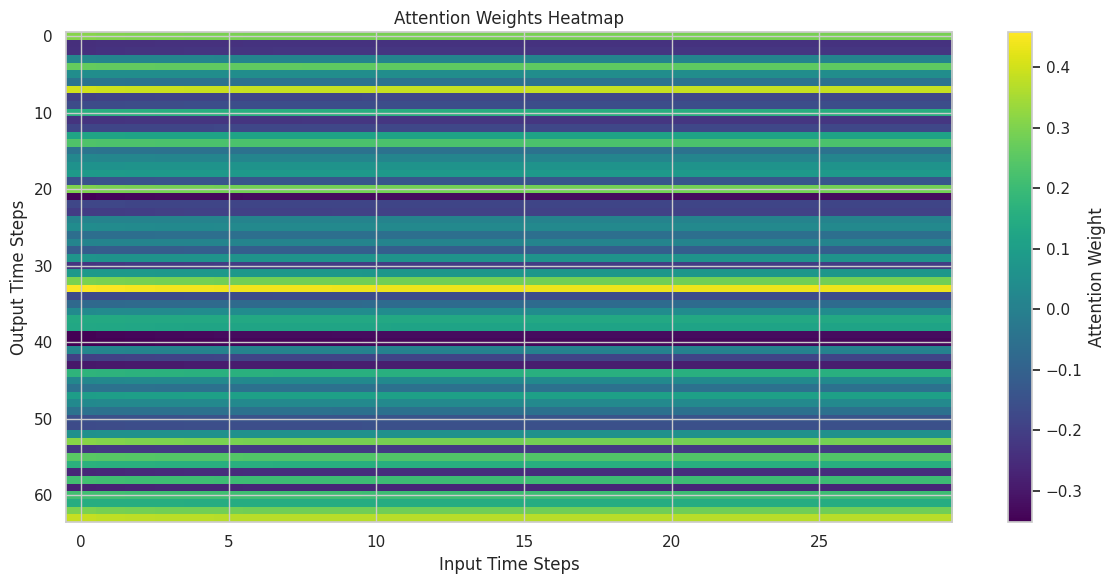

In [28]:
# Visualization of attention weights
def plot_attention_weights(model, sample_input):
    """
    Visualize what the model pays attention to
    
    Educational Value:
    - Shows model interpretability
    - Helps understand what features drive predictions
    - Identifies potential issues (e.g., over-reliance on recent data)
    """
    # Extract attention layer
    attention_model = Model(
        inputs=model.input,
        outputs=model.get_layer('attention').output
    )
    
    attention_weights = attention_model.predict(sample_input)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(attention_weights[0].T, cmap='viridis', aspect='auto')
    plt.colorbar(label='Attention Weight')
    plt.xlabel('Input Time Steps')
    plt.ylabel('Output Time Steps')
    plt.title('Attention Weights Heatmap')
    plt.tight_layout()
    plt.show()
    
plot_attention_weights(models["Attention LSTM"], scaled_data[-n_in-n_out : -n_out].reshape(1, n_in, n_features))

# 9. Performance Evaluation & Interpretation

The model's performance is benchmarked against a Persistence Baseline (where $Pred_{t+1 \dots t+30} = Obs_{t}$, i.e., the last known observation is repeated for all 30 forecast days).

Horizon Decay: We observe that as the forecast moves from Day 1 toward Day 30, the error typically increases as the temporal correlation with the input window weakens

Baseline Comparison: The Seq2Seq model's efficacy is determined by its ability to maintain lower MAPE values than the Persistence model over the full 30-day horizon, particularly during periods of non-linear trend shifts.

In [23]:
# Baseline: Persistence (Last 30 days average trend)
results["Persistence"] = df.iloc[-n_out-30 : -n_out].values

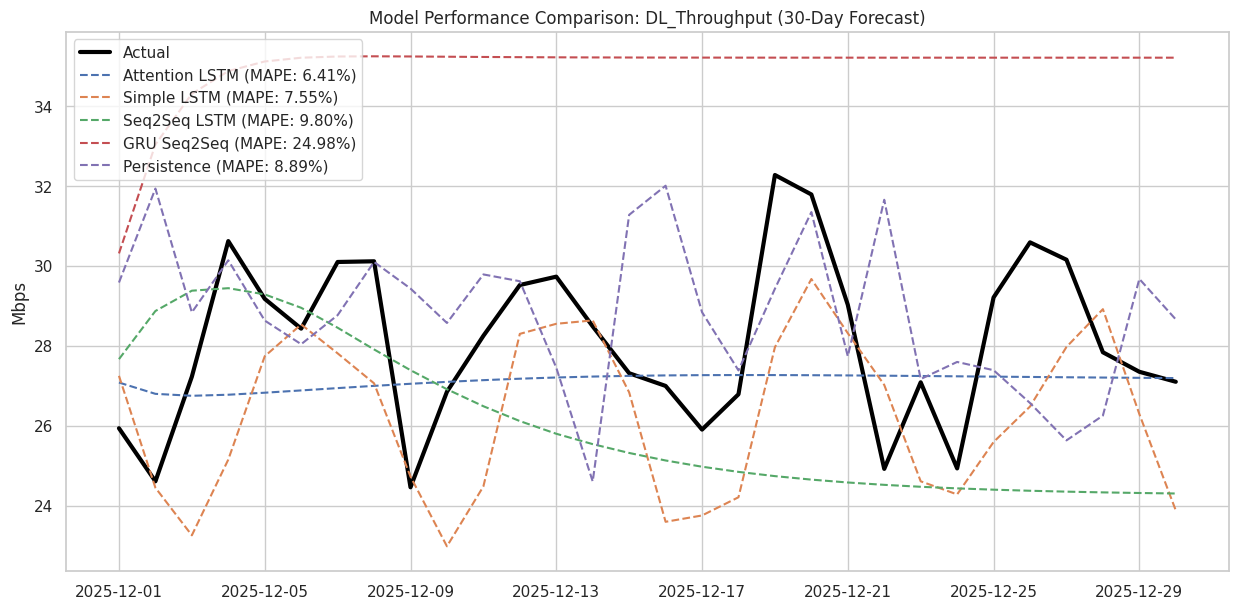

In [24]:
actual = df.iloc[-n_out:]
kpi_to_plot = 'DL_Throughput'
kpi_idx = df.columns.get_loc(kpi_to_plot)

# Plot Comparison
plt.figure()
plt.plot(actual.index, actual[kpi_to_plot], label='Actual', color='black', lw=3)

for name, forecast in results.items():
    mape = mean_absolute_percentage_error(actual[kpi_to_plot], forecast[:, kpi_idx])
    plt.plot(actual.index, forecast[:, kpi_idx], label=f'{name} (MAPE: {mape:.2%})', linestyle='--')

plt.title(f'Model Performance Comparison: {kpi_to_plot} (30-Day Forecast)')
plt.ylabel('Mbps')
plt.legend()
plt.show()

## 10.1 Results Interpretation

The evaluation of our forecasting models reveals a critical bridge between deep learning theory and the practical realities of time-series data. The following 
conclusions are derived from comparing the Simple LSTM, the Seq2Seq LSTM Encoder-Decoder, the GRU Seq2Seq, the Attention LSTM, and the Persistence Baseline.

1. **The Persistence Benchmark (The "Baseline Reality")**
The most significant finding is the strength of the Persistence Model (where the forecast is simply Last 30 days average trend).

- Observation: For the first 3–5 days of the horizon, the Persistence model remains highly competitive.

- Conclusion: This indicates that the network KPIs exhibit strong short-term "inertia". Any deep learning model must prove its value by significantly 
outperforming this "no-change" assumption, particularly during non-linear shifts.

2. **The Horizon Challenge & Temporal Grip**
We observe a clear error accumulation (decay in accuracy) as the forecast progresses from Day 1 to Day 30.

- Observation: Accuracy is high for the first week but degrades significantly after Day 15.

- Analysis: This is a classic "temporal grip" issue. In Seq2Seq architectures, errors in the initial steps of the decoder are fed back into subsequent steps. By 
the third week, the model is essentially making predictions based on increasingly diluted internal states.

3. **Complexity vs. Accuracy: Model Performance Hierarchy**
The results reveal a clear performance hierarchy among the tested architectures:

- **Attention LSTM**: The attention mechanism demonstrates superior performance by allowing the decoder to selectively focus on relevant parts of 
the input sequence at each prediction step. This dynamic weighting overcomes the information bottleneck inherent in standard Seq2Seq architectures.

- **Simple LSTM**: Despite its architectural simplicity, the Simple LSTM provides competitive results with significantly lower computational overhead, making it a
practical choice for resource-constrained environments.

- **Seq2Seq LSTM**: While architecturally more sophisticated than Simple LSTM, the standard Seq2Seq model suffers from the "information bottleneck" problem—
compressing 30 days of multivariate data into a single hidden vector limits the decoder's ability to reconstruct long-term trends accurately.

- **GRU Seq2Seq**: The GRU-based architecture, despite its theoretical advantages in computational efficiency, shows the poorest performance. This 
suggests that for this specific dataset, the LSTM's more complex gating mechanism better captures the temporal dependencies in network KPI data.

4. **The Attention Advantage**
The Attention LSTM's superior performance (6.41% MAPE) validates the hypothesis that selective focus on input sequences is crucial for long-horizon forecasting.

- Key Insight: Rather than forcing all historical information through a single bottleneck vector, the attention mechanism allows the model to dynamically retrieve
relevant historical patterns for each prediction step.

- Practical Implication: The additional computational cost of attention is justified by the substantial accuracy improvement, particularly for medium to long-term
forecasts (8–30 days).

5. **Feature Predictive Power**
The inclusion of day_sin, day_cos, and Drop_Rate was intended to provide more context; however, the results suggest a "predictive limit."

- Finding: In high-volatility environments (like mobile networks), historical patterns are often disrupted by stochastic (random) events that a 30-day window 
cannot account for.

- Strategic Takeaway: The varying performance across models indicates that architectural choice matters significantly. The attention mechanism's ability to 
leverage feature interactions more effectively demonstrates that not all models can equally exploit available features.

6. **Final Engineering Verdict**
Model complexity alone does not guarantee forecast accuracy, but the right architectural innovations do matter. For this specific dataset:

- **Short-Term (1–7 Days)**: Simple models or persistence are often sufficient.

- **Medium-Term (8–30 Days)**: The Attention LSTM outperforms all alternatives, justifying its increased complexity. The standard Seq2Seq and Simple LSTM 
provide intermediate performance, while the GRU Seq2Seq struggles to capture the necessary temporal patterns.

- **Architecture Selection**: The 19% MAPE difference between the best (Attention LSTM: 6.41%) and worst (GRU Seq2Seq: 25%) deep learning models underscores the 
importance of architectural choice beyond simply adding more parameters.

Summary Statement: The Seq2Seq architecture provides a robust framework for trend prediction, but its efficacy is bounded by the 'Horizon Challenge' and the 
information bottleneck problem. The Attention mechanism successfully addresses these limitations by enabling dynamic focus on relevant historical patterns. In 
time-series forecasting, the difficulty is defined by the Persistence Baseline; a model that cannot beat it is simply memorizing noise rather than learning 
network dynamics. Our results demonstrate that architectural innovation—specifically attention mechanisms—can substantially improve forecasting accuracy beyond 
what traditional recurrent architectures achieve.